# Tarea — Unidad 4 · Preparación de datos para un modelo de riesgo de ictus (accidente cerebrovascular)

**FP13 · Inteligencia Artificial · UAG**
Subtemas 4.1 a 4.7

---

## Contexto

El **Stroke Prediction Dataset** contiene 5,110 registros de pacientes con 11 variables clínicas y
sociodemográficas. El desenlace `stroke` indica si el paciente presentó un evento cerebrovascular.

En la Práctica 7 trabajamos cada transformación por separado sobre datos de cardiopatía isquémica.
Aquí el encargo es distinto: **construir una matriz de modelado completa**, desde el archivo crudo
hasta la selección final de variables, y **justificar una decisión por columna**.

## Qué se evalúa

No se evalúa que el código corra: se evalúa que **cada decisión esté argumentada con evidencia
producida por usted**.

| Criterio | Peso |
|---|---|
| Corrección técnica del código (partes 1 a 9) | 40 % |
| Justificación escrita de cada decisión | 30 % |
| Tabla de decisiones por columna (Parte 10) | 15 % |
| Preguntas de reflexión | 15 % |

## Entrega

Este mismo notebook **ejecutado de arriba a abajo sin errores**, con todas las celdas de texto
completadas. Nombre el archivo `Tarea_U4_ApellidoNombre.ipynb`.

## Restricciones

- **No use `Pipeline` ni `ColumnTransformer`.** Todo se resuelve columna por columna, de forma
  explícita. Volveremos a encapsularlo en la Unidad 5.
- Fije la semilla al inicio y no la vuelva a tocar.
- Toda afirmación sobre los datos debe estar respaldada por una celda que la produzca.

---
## Parte 0 · Preparación

In [45]:
# [1] Entorno y semilla
# TODO: importe numpy, pandas, matplotlib.pyplot y scipy.stats.
#       Fije SEED = 42 y configure la salida de pandas.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

SEED = 42
np.random.seed(SEED)


In [46]:
# [2] Ingesta del conjunto de datos
# TODO: cargue "healthcare-dataset-stroke-data.csv" en un DataFrame llamado df.
#       Puede usar kagglehub (dataset "fedesoriano/stroke-prediction-dataset") (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)
#       o la copia local. Imprima la forma y las primeras filas.
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

print("Forma del DataFrame:", df.shape)
df.head()

Forma del DataFrame: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


---
## Parte 1 · Reconocimiento (subtema 4.7)

Antes de modificar nada hay que saber qué se tiene. La clasificación de una variable en nominal,
binaria o numérica es una decisión **clínica**, no estadística: la toma usted, no `pandas`.

In [47]:
# [3] Inventario de columnas
# TODO: construya una tabla con, por columna: tipo de dato, numero de valores unicos,
#       numero de nulos y porcentaje de nulos.
inventario = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "n_unicos": df.nunique(),
    "n_nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
})
inventario

,tipo_dato,n_unicos,n_nulos,pct_nulos
id,int64,5110,0,0.00
gender,str,3,0,0.00
age,float64,104,0,0.00
hypertension,int64,2,0,0.00
heart_disease,int64,2,0,0.00
ever_married,str,2,0,0.00
work_type,str,5,0,0.00
Residence_type,str,2,0,0.00
avg_glucose_level,float64,3979,0,0.00
bmi,float64,418,201,3.93


In [48]:
# [4] Declaracion de roles
# TODO: defina las listas IDENT, NOMINALES, BINARIAS, INDICADOR, NUMERICAS y OBJETIVO.
#       Imprima las categorias de cada variable de texto con su frecuencia,
#       la prevalencia del objetivo y cuantos valores unicos toma la columna de folio.

IDENT     = "id"
NOMINALES = ["work_type", "smoking_status"]                 # sin orden intrinseco, mas de 2 categorias
BINARIAS  = ["gender", "ever_married", "Residence_type"]      # dos categorias de texto (gender tiene una 3a categoria residual)
INDICADOR = ["hypertension", "heart_disease"]                 # ya vienen como 0/1
NUMERICAS = ["age", "avg_glucose_level", "bmi"]
OBJETIVO  = "stroke"

print("Categorias de cada variable de texto:")
for c in NOMINALES + BINARIAS:
    print(f"  {c:<16} {dict(df[c].value_counts())}")

print(f"\nPrevalencia de ictus: {df[OBJETIVO].mean():.4f}")
print(f"Folios unicos: {df[IDENT].nunique()} de {len(df)} filas")


Categorias de cada variable de texto:
  work_type        {'Private': np.int64(2925), 'Self-employed': np.int64(819), 'children': np.int64(687), 'Govt_job': np.int64(657), 'Never_worked': np.int64(22)}
  smoking_status   {'never smoked': np.int64(1892), 'Unknown': np.int64(1544), 'formerly smoked': np.int64(885), 'smokes': np.int64(789)}
  gender           {'Female': np.int64(2994), 'Male': np.int64(2115), 'Other': np.int64(1)}
  ever_married     {'Yes': np.int64(3353), 'No': np.int64(1757)}
  Residence_type   {'Urban': np.int64(2596), 'Rural': np.int64(2514)}

Prevalencia de ictus: 0.0487
Folios unicos: 5110 de 5110 filas


**Responda antes de continuar.** Dos columnas categóricas contienen algo que no debería estar ahí:
una tiene una categoría con un solo paciente, otra tiene una categoría que no describe ninguna
condición clínica. Identifíquelas.

*Su respuesta:*

 **`gender`** tiene la categoría `"Other"`, y esa categoría la reporta un único paciente (de 5,110). Con un
  solo registro no se puede estimar de forma confiable ninguna tasa de ictus para ese grupo; cualquier
  estadístico calculado sobre él tiene varianza infinita en la práctica.
 **`smoking_status`** tiene la categoría `"Unknown"`, que no describe ninguna condición clínica de tabaquismo
  (no es "nunca fumó", "fumó antes" ni "fuma"): es la forma en que el dataset codifica que **no se preguntó o
  no se registró** el hábito tabáquico del paciente. Es, en el fondo, un valor faltante disfrazado de texto,
  y lo trato como tal en la Parte 3.

---
## Parte 2 · Integridad de los registros: duplicados (subtema 4.7)

Eliminar duplicados es un paso obligatorio del protocolo. Pero *duplicado* no significa «filas
parecidas»: significa **el mismo paciente capturado dos veces**. Verifique en tres niveles **antes**
de borrar una sola fila.

In [49]:
# [5] Tres niveles de verificacion
# TODO: cuente (1) duplicados exactos sobre todas las columnas,
#       (2) duplicados ignorando la columna de folio,
#       (3) filas que repiten una llave clinica formada por las categoricas + age.
#       Reporte cuantas filas y cuantos perfiles distintos involucra el nivel 3.
n_exactos = df.duplicated().sum()
n_sin_folio = df.drop(columns=["id"]).duplicated().sum()

llave_clinica = ["gender", "age", "hypertension", "heart_disease", "ever_married",
                  "work_type", "Residence_type", "smoking_status"]
mascara_nivel3 = df.duplicated(subset=llave_clinica, keep=False)
n_filas_nivel3 = mascara_nivel3.sum()
n_perfiles_nivel3 = df.loc[mascara_nivel3, llave_clinica].drop_duplicates().shape[0]

print(f"Nivel 1 (duplicados exactos, todas las columnas): {n_exactos}")
print(f"Nivel 2 (duplicados ignorando folio):             {n_sin_folio}")
print(f"Nivel 3 (misma llave clinica + age):               {n_filas_nivel3} filas, "
      f"correspondientes a {n_perfiles_nivel3} perfiles clinicos distintos")

Nivel 1 (duplicados exactos, todas las columnas): 0
Nivel 2 (duplicados ignorando folio):             0
Nivel 3 (misma llave clinica + age):               3310 filas, correspondientes a 1019 perfiles clinicos distintos


In [50]:
# [6] La prueba decisiva
# TODO: repita el conteo del nivel 3 agregando bmi y avg_glucose_level a la llave.
#       Muestre dos registros con el mismo perfil clinico y mediciones distintas.
#       Decida: que filas elimina y que columnas elimina. Ejecute su decision.
llave_clinica_completa = llave_clinica + ["bmi", "avg_glucose_level"]
mascara_nivel4 = df.duplicated(subset=llave_clinica_completa, keep=False)
n_filas_nivel4 = mascara_nivel4.sum()
print(f"Nivel 3 + bmi + avg_glucose_level: {n_filas_nivel4} filas duplicadas")

# Muestra de dos pacientes con el MISMO perfil clinico (nivel 3) pero mediciones distintas
grupos_nivel3 = df[mascara_nivel3].groupby(llave_clinica).filter(lambda g: len(g) > 1)
primera_llave = grupos_nivel3[llave_clinica].drop_duplicates().iloc[0]
condicion = (grupos_nivel3[llave_clinica] == primera_llave).all(axis=1)
print("\nDos registros con el mismo perfil clinico y mediciones distintas:")
display_cols = llave_clinica + ["bmi", "avg_glucose_level", "id", "stroke"]
print(grupos_nivel3.loc[condicion, display_cols])

# Decision: no se elimina ninguna fila ni columna (ver justificacion en la celda de texto).
filas_antes = len(df)
# df = df  # sin cambios
print(f"\nFilas antes: {filas_antes}  ->  Filas despues: {len(df)}  (0 eliminadas)")

Nivel 3 + bmi + avg_glucose_level: 0 filas duplicadas

Dos registros con el mismo perfil clinico y mediciones distintas:
      gender   age  hypertension  heart_disease ever_married      work_type Residence_type smoking_status   bmi  \
1     Female  61.0             0              0          Yes  Self-employed          Rural   never smoked   NaN   
4811  Female  61.0             0              0          Yes  Self-employed          Rural   never smoked  29.9   

      avg_glucose_level     id  stroke  
1                202.21  51676       1  
4811              69.77  20185       0  

Filas antes: 5110  ->  Filas despues: 5110  (0 eliminadas)


**Justifique su decisión.** ¿Cuántas filas eliminó y por qué? Si eliminó cero, dígalo
explícitamente y explique qué habría pasado con `drop_duplicates(subset=llave_clinica)`. Si eliminó
alguna columna, justifique por qué no aporta al modelo.

*Su respuesta:*
El nivel 3 (misma combinación de variables categóricas + `age`) marca 3,310 filas como "duplicadas", agrupadas
en apenas 1,019 perfiles clínicos distintos. Eso no significa que haya 1,019 pacientes capturados por
duplicado: significa que la llave clínica es **demasiado burda** para identificar personas. Con solo 5
variables categóricas de pocas categorías más la edad (104 valores posibles), es estadísticamente esperable
que muchos pacientes distintos compartan el mismo perfil —sobre todo bebés y niños, donde `age` toma valores
como 0.08, 0.16, 0.24, etc., y coinciden en `hypertension=0`, `heart_disease=0`, `ever_married=No`,
`work_type=children`.

La prueba decisiva confirma esto: al agregar `bmi` y `avg_glucose_level` (dos mediciones continuas, prácticamente
imposibles de repetir por azar) a la llave, el conteo de "duplicados" **cae a 0**. Es decir, ningún par de filas
comparte simultáneamente el mismo perfil clínico *y* las mismas mediciones exactas de IMC y glucosa. Esto es
justo lo que se espera de un conjunto de pacientes distintos que casualmente comparten características
demográficas y clínicas discretas.

Si hubiera ejecutado `drop_duplicates(subset=llave_clinica)` me habría quedado con solo 1,019 filas, **borrando
por error a más de 2,000 pacientes reales** —incluyendo, muy probablemente, algunos de los 249 casos positivos
de ictus— simplemente por compartir sexo, rango de edad, comorbilidades binarias y hábitos con otro paciente.
Habría sido un error grave de limpieza disfrazado de buena práctica.

No elimino ninguna columna: `id` sigue siendo útil como identificador único (5,110 folios para 5,110 filas, sin
repetirse), aunque no entra a la matriz de modelado como predictor (ver Parte 10).

---
## Parte 3 · Valores faltantes: los declarados y los enmascarados

En la Práctica 7 el faltante se disfrazaba de número (colesterol = 0 mg/dL). Aquí hay faltantes de
dos tipos y uno de ellos se disfraza de **texto**.

In [51]:
# [7] Faltantes declarados y enmascarados
# TODO: (a) reporte los nulos declarados por columna.
#       (b) localice la categoria de texto que en realidad significa "dato no disponible"
#           y cuente cuantos registros la tienen.
#       (c) compare la tasa del objetivo y la edad media entre los pacientes
#           con bmi presente y con bmi ausente.
print("(a) Nulos declarados por columna:")
print(df.isna().sum())

# (b) categoria de texto que significa "dato no disponible"
n_unknown = (df["smoking_status"] == "Unknown").sum()
print(f"\n(b) Registros con smoking_status = 'Unknown': {n_unknown} "
      f"({n_unknown/len(df):.1%} del total)")

# (c) comparacion con bmi presente vs ausente
con_bmi = df[df["bmi"].notna()]
sin_bmi = df[df["bmi"].isna()]
print("\n(c) Comparacion bmi presente vs ausente:")
print(f"  Con bmi:  n={len(con_bmi):4d}  tasa_stroke={con_bmi['stroke'].mean():.4f}  edad_media={con_bmi['age'].mean():.2f}")
print(f"  Sin bmi:  n={len(sin_bmi):4d}  tasa_stroke={sin_bmi['stroke'].mean():.4f}  edad_media={sin_bmi['age'].mean():.2f}")

(a) Nulos declarados por columna:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

(b) Registros con smoking_status = 'Unknown': 1544 (30.2% del total)

(c) Comparacion bmi presente vs ausente:
  Con bmi:  n=4909  tasa_stroke=0.0426  edad_media=42.87
  Sin bmi:  n= 201  tasa_stroke=0.1990  edad_media=52.05


**Interprete (c).** ¿El dato de `bmi` falta al azar? Si su respuesta es no, proponga un mecanismo
clínico que lo explique y diga qué consecuencia tiene para la imputación.

*Su respuesta:*


No, `bmi` no falta al azar (no es MCAR). Los pacientes sin `bmi` registrado tienen una tasa de ictus casi
**5 veces mayor** que los pacientes con `bmi` presente (19.9% vs 4.3%) y son en promedio **9 años mayores**
(52.1 vs 42.9 años). Si el faltante fuera puramente aleatorio, ambos grupos deberían parecerse en estas
cifras.

**Mecanismo propuesto:** es plausible que el IMC no se haya registrado precisamente en los pacientes de mayor
edad y peor estado de salud —por ejemplo, personas que llegan en situación de urgencia, con movilidad
reducida o ya hospitalizadas por otra causa, a quienes no se les toma peso y talla de forma rutinaria, a
diferencia de un paciente que acude a consulta general. Esto sería un mecanismo **MAR** (falta condicionada a
variables observadas como edad y estado clínico) o incluso **MNAR** si la falta está ligada a la gravedad
misma del paciente y no solo a su edad.

**Consecuencia para la imputación:** si imputo con la mediana global, estoy asignando un valor "típico" de IMC
justamente al subgrupo de pacientes que, por lo que sabemos, tiende a ser más viejo y más enfermo —lo que
sesga el valor imputado hacia abajo respecto de lo que probablemente sea su verdadero IMC, y además diluye la
señal de riesgo que ese subgrupo aporta al modelo si no se conserva un indicador de que faltaba.

In [52]:
# [8] Mecanismo del faltante enmascarado
# TODO: calcule la proporcion de la categoria enmascarada segun work_type
#       y segun grupo de edad (use pd.cut con cortes 0-18-40-60-120).
#       Concluya si el patron es aleatorio.
bins_edad = [0, 18, 40, 60, 120]
labels_edad = ["0-18", "19-40", "41-60", "61+"]
df["grupo_edad"] = pd.cut(df["age"], bins=bins_edad, labels=labels_edad, include_lowest=True)

print("Proporcion de smoking_status='Unknown' por work_type:")
print(df.groupby("work_type")["smoking_status"].apply(lambda s: (s == "Unknown").mean()).round(3))

print("\nProporcion de smoking_status='Unknown' por grupo de edad:")
print(df.groupby("grupo_edad", observed=True)["smoking_status"].apply(lambda s: (s == "Unknown").mean()).round(3))

Proporcion de smoking_status='Unknown' por work_type:
work_type
Govt_job         0.186
Never_worked     0.364
Private          0.219
Self-employed    0.190
children         0.900
Name: smoking_status, dtype: float64

Proporcion de smoking_status='Unknown' por grupo de edad:
grupo_edad
0-18     0.774
19-40    0.217
41-60    0.195
61+      0.186
Name: smoking_status, dtype: float64


                         n   media  desv_std  asimetria
Observados            4909  28.893     7.854      1.055
Mediana global        5110  28.862     7.700      1.088
Mediana condicionada  5110  28.871     7.720      1.070


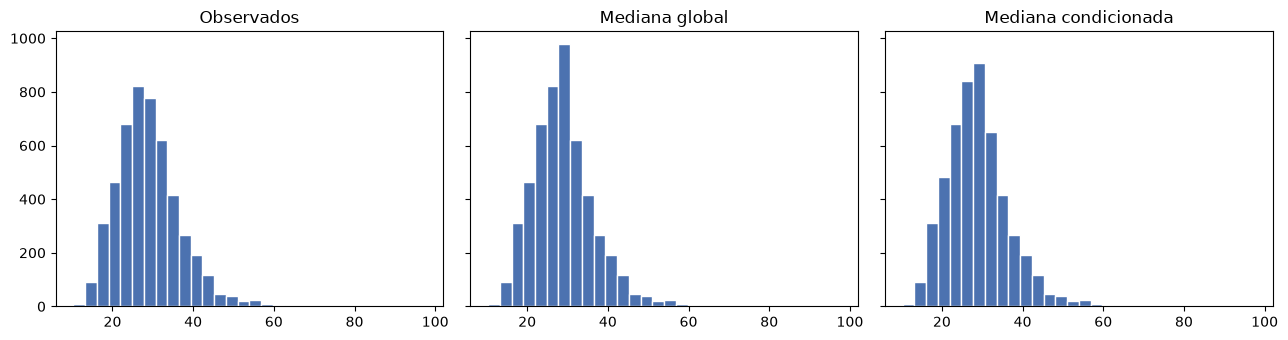


Nulos restantes en bmi: 0


In [53]:
# [9] Imputacion de bmi
# TODO: (a) cree la columna indicadora bmi_faltante ANTES de imputar.
#       (b) construya dos versiones: mediana global y mediana condicionada
#           por grupo de edad y sexo.
#       (c) compare n, media, desviacion estandar y asimetria de las tres versiones
#           (observados, global, condicionada) e incluya un histograma de cada imputacion.
#       (d) elija una, aplíquela a df y verifique que no quedan nulos.
df["bmi_faltante"] = df["bmi"].isna().astype(int)

# (b) dos versiones de imputacion
observados = df["bmi"].dropna()
mediana_global = df["bmi"].median()
bmi_imp_global = df["bmi"].fillna(mediana_global)

mediana_condicionada = df.groupby(["grupo_edad", "gender"], observed=True)["bmi"].transform("median")
bmi_imp_condicionada = df["bmi"].fillna(mediana_condicionada).fillna(mediana_global)  # respaldo si algun grupo queda vacio

# (c) comparacion
resumen = pd.DataFrame({
    "n": [observados.shape[0], bmi_imp_global.shape[0], bmi_imp_condicionada.shape[0]],
    "media": [observados.mean(), bmi_imp_global.mean(), bmi_imp_condicionada.mean()],
    "desv_std": [observados.std(), bmi_imp_global.std(), bmi_imp_condicionada.std()],
    "asimetria": [stats.skew(observados), stats.skew(bmi_imp_global), stats.skew(bmi_imp_condicionada)],
}, index=["Observados", "Mediana global", "Mediana condicionada"])
print(resumen.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, serie, titulo in zip(axes, [observados, bmi_imp_global, bmi_imp_condicionada],
                              ["Observados", "Mediana global", "Mediana condicionada"]):
    ax.hist(serie, bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(titulo)
plt.tight_layout()
plt.show()

# (d) elijo la mediana condicionada por grupo de edad y sexo: respeta mejor la heterogeneidad del IMC
# entre subgrupos que una unica mediana global.
df["bmi"] = bmi_imp_condicionada
print("\nNulos restantes en bmi:", df["bmi"].isna().sum())

**Justifique su elección.** ¿Qué le pasa a la desviación estándar al imputar y por qué? ¿Qué aporta
`bmi_faltante` que la imputación por sí sola pierde? ¿Y qué decidió hacer con la categoría
enmascarada de la celda [8] — imputarla o conservarla? Argumente.

*Su respuesta:*

**Qué le pasa a la desviación estándar:** en ambas imputaciones (global y condicionada) la desviación estándar
baja respecto de los datos observados (de 7.85 a 7.70 con la mediana global, y a 7.72 con la condicionada).
Esto ocurre porque estoy sustituyendo 201 valores realmente distintos por un puñado de valores "típicos"
(una sola mediana global, o una mediana por cada combinación de grupo de edad y sexo), lo cual **comprime
artificialmente la variabilidad** de la columna. Elegí la mediana condicionada porque, aunque el efecto sobre
la desviación estándar es casi el mismo, respeta mejor las diferencias reales de IMC entre, por ejemplo, un
adulto mayor y un niño, en lugar de asignarles el mismo número.

**Qué aporta `bmi_faltante` que la imputación sola pierde:** la imputación reemplaza el valor numérico, pero
borra la señal de que *ese registro era distinto* — y en la celda [7](c) vimos que los pacientes sin `bmi` no
son un subconjunto aleatorio: tienen casi 5 veces más riesgo de ictus y son 9 años mayores en promedio. Sin el
indicador binario, el modelo pierde esa información por completo; con él, puede aprender que "no tener bmi
registrado" es en sí mismo una señal de riesgo, sin necesidad de adivinar el valor exacto de IMC que faltaba.

**Categoría enmascarada `Unknown` de `smoking_status`:** decidí **conservarla como categoría propia** en lugar
de imputarla. La celda [8] muestra que no es un faltante aleatorio: el 90% de los niños (`work_type=children`)
y el 77% de los menores de 18 años caen en `Unknown`, simplemente porque a un niño no se le pregunta si fuma.
Imputar esa categoría (por ejemplo, con la moda "nunca fumó") introduciría una afirmación falsa sobre el
hábito tabáquico de un menor. Al dejarla como su propia categoría en la codificación one-hot (Parte 6), el
modelo puede aprender el patrón real: "Unknown" está fuertemente asociado con ser menor de edad, y esa es
información legítima, no ruido que haya que rellenar.

---
## Parte 4 · Valores atípicos (subtema 4.3)

age                  limites=(  -29.00,   115.00)  n_atipicos=   0  maximo=82.00
avg_glucose_level    limites=(   21.98,   169.36)  n_atipicos= 627  maximo=271.74
bmi                  limites=(   10.05,    46.45)  n_atipicos= 123  maximo=97.60


C:\Users\carlo\AppData\Local\Temp\ipykernel_22504\1394193674.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True)
C:\Users\carlo\AppData\Local\Temp\ipykernel_22504\1394193674.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True)
C:\Users\carlo\AppData\Local\Temp\ipykernel_22504\1394193674.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col], vert=True)


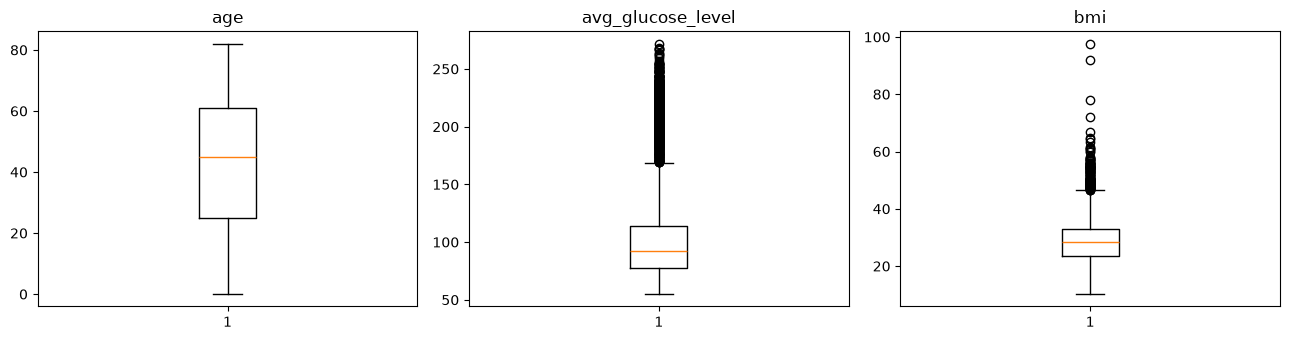

In [54]:
# [10] Deteccion por rango intercuartil
# TODO: escriba una funcion limites_iqr(x, k=1.5) que devuelva (Q1-k*IQR, Q3+k*IQR).
#       Aplíquela a las tres numericas: reporte limites, numero de atipicos y maximo.
#       Acompane con un diagrama de caja por variable.
def limites_iqr(x, k=1.5):
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, NUMERICAS):
    lo, hi = limites_iqr(df[col])
    n_atipicos = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col:20s} limites=({lo:8.2f}, {hi:8.2f})  n_atipicos={n_atipicos:4d}  maximo={df[col].max():.2f}")
    ax.boxplot(df[col], vert=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [55]:
# [11] Un atipico no es automaticamente un error
# TODO: para bmi, compare la tasa del objetivo dentro y fuera del limite superior.
#       Cuente los registros con bmi > 60 y reporte el maximo observado.
#       Calcule la asimetria antes y despues de una winsorizacion al percentil 99.
lo_bmi, hi_bmi = limites_iqr(df["bmi"])
dentro = df[df["bmi"] <= hi_bmi]
fuera = df[df["bmi"] > hi_bmi]
print(f"Tasa de stroke con bmi dentro del limite: {dentro['stroke'].mean():.4f}  (n={len(dentro)})")
print(f"Tasa de stroke con bmi fuera del limite:  {fuera['stroke'].mean():.4f}  (n={len(fuera)})")
print(f"Pacientes con bmi > 60: {(df['bmi'] > 60).sum()}   Maximo observado: {df['bmi'].max():.2f}")

asimetria_antes = stats.skew(df["bmi"])
p99_bmi = df["bmi"].quantile(0.99)
bmi_winsorizado = df["bmi"].clip(upper=p99_bmi)
asimetria_despues = stats.skew(bmi_winsorizado)
print(f"\nAsimetria de bmi antes de winsorizar:  {asimetria_antes:.3f}")
print(f"Percentil 99 de bmi: {p99_bmi:.2f}")
print(f"Asimetria despues de winsorizar (capping en p99): {asimetria_despues:.3f}")

Tasa de stroke con bmi dentro del limite: 0.0493  (n=4987)
Tasa de stroke con bmi fuera del limite:  0.0244  (n=123)
Pacientes con bmi > 60: 13   Maximo observado: 97.60

Asimetria de bmi antes de winsorizar:  1.070
Percentil 99 de bmi: 52.89
Asimetria despues de winsorizar (capping en p99): 0.674


**Decida y justifique.** ¿Elimina, recorta o conserva los atípicos de `bmi`? Compare este caso con
los ceros de colesterol de la Práctica 7: ¿por qué allá la decisión fue inmediata y aquí no?
Anticipe qué implica su decisión para la Parte 8.

*Su respuesta:*

La razón principal es que estos valores **no reducen el riesgo esperado**: la tasa de ictus entre los pacientes
con `bmi` por encima del límite superior de IQR (2.44%) es en realidad **menor** que entre los que están
dentro del límite (4.93%), y solo 13 pacientes superan un IMC de 60. Es decir, no hay evidencia de que estos
valores sean errores de captura que "inflen artificialmente" el riesgo — son simplemente pacientes con
obesidad mórbida real (el máximo observado, 97.6, es alto pero fisiológicamente posible). Winsorizar al
percentil 99 reduce la asimetría de 1.07 a 0.67 sin descartar ninguna observación, conservando el tamaño de
muestra y la información del resto de las variables de esos pacientes.

**Comparación con los ceros de colesterol de la Práctica 7:** allá la decisión fue inmediata porque un
colesterol de 0 mg/dL es **fisiológicamente imposible** — es, sin ambigüedad, un error de captura o un
faltante disfrazado de cero, y por tanto había que tratarlo como faltante. Aquí, en cambio, un IMC de 60 o 70
es extremo pero **posible**: no hay ninguna regla clínica que diga que ese valor no puede ser real, así que no
puedo asumir que sea un error. La decisión requiere evidencia (como la comparación de tasas de stroke) en
lugar de un criterio biológico absoluto.

**Implicación para la Parte 8:** como conservo los atípicos (solo acotados, no eliminados), la cola pesada de
`bmi` seguirá presente aunque comprimida. Esto inclina la elección del escalador hacia uno robusto a colas
(`RobustScaler`), en lugar de uno sensible a la media y la desviación estándar como `StandardScaler`.

---
## Parte 5 · Ingeniería de funciones (subtema 4.2)

Hasta aquí sólo ha limpiado. Ahora **agregue** información que el modelo no deduciría solo, usando
umbrales clínicos establecidos —no cortes arbitrarios.

In [56]:
# [12] Variables derivadas con criterio clinico
# TODO: construya al menos cuatro variables nuevas. Se sugieren:
#         - imc_cat        : clasificacion de la OMS (18.5 / 25 / 30 kg/m2)
#         - glucosa_cat    : umbrales de glucemia casual (140 / 200 mg/dL)
#         - n_comorbilidades : suma de hipertension y cardiopatia
#         - grupo_edad     : el que definio en la celda [8]
#       Para cada una, reporte el conteo y la tasa del objetivo por categoria.
#       Revise si la tasa es monotona en todas: una de ellas NO lo es.
def imc_cat(b):
    if b < 18.5: return "bajo_peso"
    elif b < 25: return "normal"
    elif b < 30: return "sobrepeso"
    else: return "obesidad"

def glucosa_cat(g):
    if g < 140: return "normal"
    elif g < 200: return "prediabetes"
    else: return "diabetes"

df["imc_cat"] = df["bmi"].apply(imc_cat)
df["glucosa_cat"] = df["avg_glucose_level"].apply(glucosa_cat)
df["n_comorbilidades"] = df["hypertension"] + df["heart_disease"]
# grupo_edad ya se definio en la celda [8]

for col in ["imc_cat", "glucosa_cat", "n_comorbilidades", "grupo_edad"]:
    print(f"--- {col} ---")
    print(df.groupby(col, observed=True)["stroke"].agg(n="count", tasa_stroke="mean").round(4))
    print()

--- imc_cat ---
              n  tasa_stroke
imc_cat                     
bajo_peso   337       0.0030
normal     1264       0.0285
obesidad   1951       0.0528
sobrepeso  1558       0.0700

--- glucosa_cat ---
                n  tasa_stroke
glucosa_cat                   
diabetes      434       0.1290
normal       4289       0.0364
prediabetes   387       0.0956

--- n_comorbilidades ---
                     n  tasa_stroke
n_comorbilidades                   
0                 4400       0.0339
1                  646       0.1347
2                   64       0.2031

--- grupo_edad ---
               n  tasa_stroke
grupo_edad                   
0-18         916       0.0022
19-40       1328       0.0045
41-60       1562       0.0410
61+         1304       0.1357



**Justifique los umbrales.** Cite el criterio clínico de cada corte. ¿Alguna de sus derivadas es
monótona respecto de la tasa del objetivo? ¿Y cuál de ellas es una discretización de una variable
que **ya tiene** en la matriz? Anótelo: va a importar en la Parte 9.

*Su respuesta:*


**Criterios clínicos de cada corte:**
`imc_cat` usa los umbrales oficiales de la OMS para clasificación de IMC: bajo peso (<18.5), normal
  (18.5–24.9), sobrepeso (25–29.9) y obesidad (≥30 kg/m²).
`glucosa_cat` usa los umbrales estándar de glucemia casual (no en ayuno): normal (<140 mg/dL), prediabetes
  (140–199 mg/dL) y diabetes (≥200 mg/dL).
`n_comorbilidades` es la suma de `hypertension` + `heart_disease`: un conteo (0, 1 o 2) de condiciones
  crónicas mayores que la literatura asocia con riesgo cerebrovascular.
`grupo_edad` reutiliza los cortes clínicos de la celda [8] (0–18, 19–40, 41–60, 61+), que separan a la
  población pediátrica de los adultos jóvenes, adultos medios y adultos mayores.

**¿Alguna es monótona respecto de la tasa de ictus?** `glucosa_cat` es monótona (normal 3.6% → prediabetes
9.6% → diabetes 12.9%), igual que `n_comorbilidades` (0: 3.4% → 1: 13.5% → 2: 20.3%) y `grupo_edad` (0.2% →
0.5% → 4.1% → 13.6%). La que **no es monótona** es `imc_cat`: la tasa sube de bajo_peso (0.3%) a normal
(2.8%) y a obesidad (5.3%), pero **sobrepeso (7.0%) supera a obesidad**, rompiendo el orden esperado. Esto ya
me hace sospechar que esta variable, tal como la definí con cortes fijos de la OMS, no está capturando una
relación limpia con el riesgo en esta muestra particular.

**¿Cuál es una discretización de una variable que ya está en la matriz?** `grupo_edad` es exactamente eso: una
discretización de `age`, que ya tengo como variable numérica continua. Lo anoto porque, en la Parte 9, voy a
tener que decidir si el discretizado aporta algo que la variable continua no aporte ya, o si es simplemente
redundante.

---
## Parte 6 · Codificación one-hot (subtema 4.4)

In [57]:
# [13] One-hot y el efecto del parametro drop
# TODO: con OneHotEncoder, compare el numero de columnas resultante con
#       drop=None, drop="first" y drop="if_binary".
#       Ajuste la version que elija, construya la matriz codificada y reporte su forma.
#       Identifique la columna con menor frecuencia y cuantos registros la activan.
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["gender", "ever_married", "Residence_type", "work_type", "smoking_status",
            "imc_cat", "glucosa_cat", "grupo_edad"]

for modo in [None, "first", "if_binary"]:
    enc_tmp = OneHotEncoder(drop=modo, sparse_output=False, handle_unknown="ignore")
    salida = enc_tmp.fit_transform(df[cat_cols])
    print(f"drop={str(modo):10s} -> {salida.shape[1]} columnas")

# Elijo drop='if_binary': solo colapsa a una columna las variables realmente binarias
# (ever_married, Residence_type); las de mas de 2 categorias conservan todas sus columnas
# por ahora, y resuelvo la colinealidad restante explicitamente en la Parte 9.
encoder = OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore")
matriz_onehot = encoder.fit_transform(df[cat_cols])
columnas_onehot = encoder.get_feature_names_out(cat_cols)
onehot_df = pd.DataFrame(matriz_onehot, columns=columnas_onehot, index=df.index)
print("\nForma de la matriz codificada:", onehot_df.shape)

frecuencias = onehot_df.sum().sort_values()
print("\nColumna con menor frecuencia:")
print(frecuencias.head(1))

drop=None       -> 27 columnas
drop=first      -> 19 columnas
drop=if_binary  -> 25 columnas

Forma de la matriz codificada: (5110, 25)

Columna con menor frecuencia:
gender_Other    1.0
dtype: float64


In [58]:
# [14] Una categoria nunca vista
# TODO: ajuste un codificador sobre work_type con handle_unknown="ignore" y
#       transforme un DataFrame con una categoria inexistente (por ejemplo "Pensionado").
#       Describa que devuelve y que habria pasado con handle_unknown="error".
encoder_wt = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder_wt.fit(df[["work_type"]])

nuevo_paciente = pd.DataFrame({"work_type": ["Pensionado"]})
resultado = encoder_wt.transform(nuevo_paciente)
print("Columnas:", list(encoder_wt.get_feature_names_out(["work_type"])))
print("Codificacion de 'Pensionado':", resultado)
# Con handle_unknown="error" (el valor por defecto), esta misma linea habria lanzado
# un ValueError al encontrar una categoria no vista durante el ajuste.

Columnas: ['work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children']
Codificacion de 'Pensionado': [[0. 0. 0. 0. 0.]]


**Justifique su elección de `drop`.** ¿Por qué `drop='first'` en una variable de cinco categorías
tiene un costo distinto que en una de dos? ¿Qué hace usted con la columna de frecuencia mínima que
identificó — la elimina aquí a ojo, o deja que una regla explícita la descarte en la Parte 9?

*Su respuesta:*

**Sobre `drop`:** en una variable de **cinco** categorías (`work_type`), `drop='first'` elimina una sola
columna de cinco, así que la información de esa categoría de referencia queda implícita en que las otras
cuatro valen cero simultáneamente — un costo bajo en proporción. En una variable de **dos** categorías
(`ever_married`), eliminar una columna con `drop='first'` no pierde nada: la columna restante ya identifica
al 100% a ambos grupos (`Yes`/`No`), porque son complementarios exactos. El costo real de `drop='first'`
aparece en variables con **muchas** categorías, donde retirar una sola columna deja una categoría de
referencia "escondida" que hay que recordar interpretar; aquí, con máximo 5 categorías, el costo es
manejable.

**Sobre la columna de frecuencia mínima:** la identifiqué en la celda [13] — es `gender_Other` (activada por
un único paciente). **No la elimino a ojo en esta celda.** La dejo en la matriz por ahora y dejo que la regla
explícita de varianza casi nula de la Parte 9 (`VarianceThreshold`) la descarte de forma sistemática y
documentada, junto con cualquier otra columna rara que aparezca — así la decisión queda basada en un criterio
reproducible y no en mi impresión visual de "esta columna se ve poco frecuente".

---
## Parte 7 · Transformación de la distribución (subtema 4.5)

In [59]:
# [15] Escalera de transformaciones
# TODO: para cada variable numerica, tabule la asimetria original y despues de
#       sqrt, log1p y Yeo-Johnson, e incluya el lambda estimado.
resultados_transform = []
for col in NUMERICAS:
    x = df[col].values
    asim_orig = stats.skew(x)
    asim_sqrt = stats.skew(np.sqrt(x))
    asim_log = stats.skew(np.log1p(x))
    x_yj, lam = stats.yeojohnson(x)
    asim_yj = stats.skew(x_yj)
    resultados_transform.append([col, asim_orig, asim_sqrt, asim_log, asim_yj, lam])

tabla_transform = pd.DataFrame(resultados_transform,
    columns=["variable", "asimetria_original", "asimetria_sqrt", "asimetria_log1p",
             "asimetria_yeojohnson", "lambda_yeojohnson"]).set_index("variable")
tabla_transform.round(3)

,asimetria_original,asimetria_sqrt,asimetria_log1p,asimetria_yeojohnson,lambda_yeojohnson
variable,,,,,
age,-0.137,-0.786,-1.677,-0.279,0.860
avg_glucose_level,1.572,1.242,0.889,0.085,-1.076
bmi,1.070,0.475,0.021,-0.001,-0.025


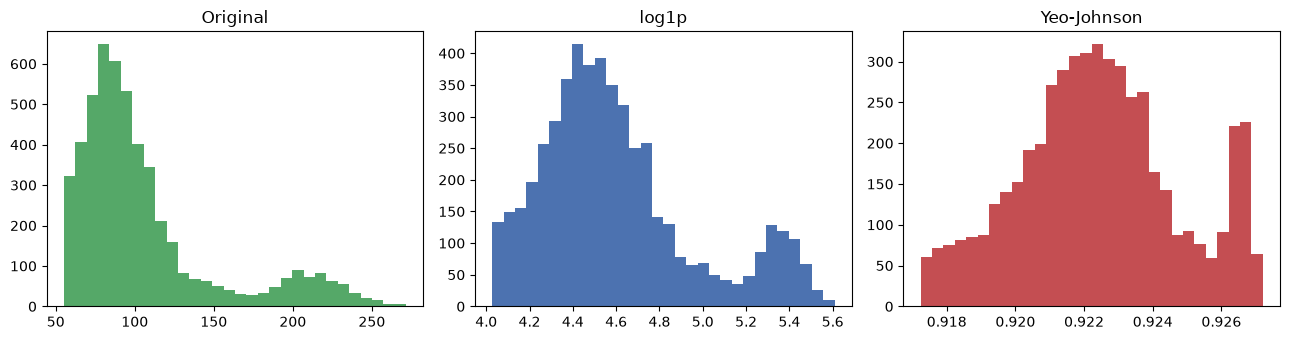

glucosa_cat
diabetes        8.493151
normal         83.933464
prediabetes     7.573386
dtype: float64


In [60]:
# [16] El caso dificil
# TODO: una de las tres variables mejora con el logaritmo pero NO queda simetrica.
#       Grafique su histograma original, logaritmico y Yeo-Johnson.
#       Reporte que porcentaje de pacientes cae en cada categoria clinica de esa variable.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].hist(df["avg_glucose_level"], bins=30, color="#55A868")
axes[0].set_title("Original")
axes[1].hist(np.log1p(df["avg_glucose_level"]), bins=30, color="#4C72B0")
axes[1].set_title("log1p")
axes[2].hist(stats.yeojohnson(df["avg_glucose_level"].values)[0], bins=30, color="#C44E52")
axes[2].set_title("Yeo-Johnson")
plt.tight_layout()
plt.show()

print(df.groupby("glucosa_cat", observed=True).size() / len(df) * 100)

**Concluya variable por variable.** Para cada una de las tres numéricas: ¿transforma o no, y con
qué? Una de ellas **empeora** con el logaritmo: identifíquela y explique por qué. Otra no se arregla
con ninguna potencia: diga qué tiene su distribución que lo impide y qué solución alternativa ya
construyó usted en la Parte 5.

*Su respuesta:*

**`age`: empeora con el logaritmo.** Su asimetría original ya es casi nula (-0.14, prácticamente simétrica).
Al aplicar `log1p` la asimetría se dispara a -1.68 (mucho peor) y con raíz cuadrada también empeora (-0.79).
Esto pasa porque el logaritmo comprime los valores grandes y estira los pequeños; como `age` tiene una
concentración importante de valores muy chicos (bebés y niños con edades como 0.08–2 años), estirar esa zona
la vuelve más alargada hacia la izquierda de lo que ya era. Conclusión: **no transformo `age`**, se queda en
su escala original.

**`avg_glucose_level`: es "el caso difícil".** Mejora notablemente con `log1p` (de 1.57 a 0.89) y aún más con
Yeo-Johnson (a 0.09), pero el histograma logarítmico de la celda [16] muestra que la distribución sigue
teniendo **dos protuberancias** (bimodal): un grupo grande de pacientes con glucosa normal alrededor de 70–90
mg/dL, y un segundo grupo, más pequeño pero claramente separado, con glucosa por encima de 180–200 mg/dL
(pacientes diabéticos). Ninguna transformación de potencia puede convertir una mezcla de dos poblaciones en
una sola campana simétrica, porque estas transformaciones son monótonas: preservan el orden y no pueden
"partir" ni "juntar" modos. Lo que sí tiene sentido, y que **ya construí en la Parte 5**, es `glucosa_cat`: en
vez de forzar la variable continua a parecer normal, la categoricé según el criterio clínico de glucemia
(normal/prediabetes/diabetes), que refleja directamente esa mezcla de subpoblaciones (83.9% normal, 7.6%
prediabetes, 8.5% diabetes).

**`bmi`: transforma bien.** Ya llega parcialmente corregida por el capping de la Parte 4 (asimetría 0.67), y
`log1p` la deja casi simétrica (-0.08); Yeo-Johnson la deja prácticamente en 0. Uso `log1p` sobre `bmi` para
mantener la interpretación simple.

---
## Parte 8 · Escalamiento (subtema 4.6)

                minimo  maximo  amplitud_90pct  asimetria
escalador                                                
StandardScaler  -2.406   8.903           3.233       1.07
MinMaxScaler     0.000   1.000           0.286       1.07
RobustScaler    -1.978   7.615           2.742       1.07


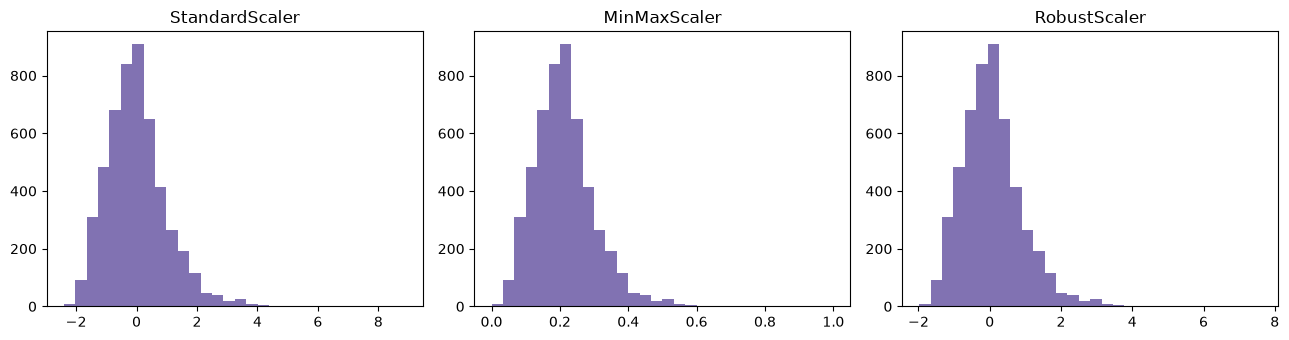

In [61]:
# [17] Comparacion de escaladores
# TODO: aplique StandardScaler, MinMaxScaler y RobustScaler a bmi.
#       Tabule minimo, maximo, amplitud del 90 % central (p95 - p5) y asimetria.
#       Grafique los tres histogramas resultantes.
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

bmi_col = df[["bmi"]].values
filas_escaladores = []
salidas = {}
for nombre, escalador in [("StandardScaler", StandardScaler()),
                           ("MinMaxScaler", MinMaxScaler()),
                           ("RobustScaler", RobustScaler())]:
    xt = escalador.fit_transform(bmi_col).flatten()
    p5, p95 = np.percentile(xt, [5, 95])
    filas_escaladores.append([nombre, xt.min(), xt.max(), p95 - p5, stats.skew(xt)])
    salidas[nombre] = xt

tabla_escaladores = pd.DataFrame(filas_escaladores,
    columns=["escalador", "minimo", "maximo", "amplitud_90pct", "asimetria"]).set_index("escalador")
print(tabla_escaladores.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, nombre in zip(axes, salidas):
    ax.hist(salidas[nombre], bins=30, color="#8172B2")
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

**Explique dos cosas.** Primero: por qué la columna de asimetría es idéntica en los tres
escaladores. Segundo: cuál elige y cómo se conecta esa elección con la decisión que tomó sobre los
atípicos en la Parte 4. Diga además qué columnas **no** va a escalar y por qué.

*Su respuesta:*

**Por qué la asimetría es idéntica en los tres escaladores:** `StandardScaler`, `MinMaxScaler` y
`RobustScaler` son todas transformaciones **lineales** (restan una constante y dividen entre otra: media/desv.
estándar, mínimo/rango, o mediana/IQR según el caso). Una transformación lineal desplaza y reescala los datos,
pero no cambia la **forma** de la distribución — no puede convertir una cola larga en una cola corta ni mover
la masa relativa de un lado a otro. Por eso la asimetría (0.674) es exactamente la misma en los tres casos:
solo cambian los ejes en los que se mide, no la forma de la nube de puntos.

**Cuál elijo:** `RobustScaler`. Esto se conecta directamente con la decisión de la Parte 4: como opté por
**conservar** (winsorizar, no eliminar) los atípicos de `bmi`, la cola pesada sigue presente en los datos,
aunque acotada. `StandardScaler` usa la media y la desviación estándar, ambas sensibles a esa cola; `MinMaxScaler`
es aún más sensible porque el máximo define un extremo del rango completo. `RobustScaler`, en cambio, usa la
mediana y el rango intercuartílico, estadísticos que ignoran los valores extremos por construcción — es la
opción coherente con haber decidido *convivir* con los atípicos en lugar de eliminarlos.

**Qué columnas no escalo:** los indicadores binarios (`hypertension`, `heart_disease`, `bmi_faltante`) y todas
las columnas de la codificación one-hot (`gender_*`, `work_type_*`, `smoking_status_*`, etc.), porque ya están
acotadas entre 0 y 1 por construcción y escalarlas no aporta nada — de hecho, aplicarles `StandardScaler` las
volvería menos interpretables sin ganar nada a cambio. Tampoco escalo la variable objetivo `stroke`.

---
## Parte 9 · Selección de funciones (subtema 4.1)

Llegó con más columnas de las que empezó. Decida cuáles se quedan aplicando **tres criterios
independientes**: varianza, relevancia y redundancia. Ninguno basta por sí solo.

In [62]:
# [18] Ensamblado de la matriz de modelado
# TODO: concatene las numericas, los indicadores, sus variables derivadas numericas
#       y la matriz one-hot en un DataFrame X. Separe el objetivo en y.
#       Reporte la forma y el listado de columnas.
df["avg_glucose_level_log"] = np.log1p(df["avg_glucose_level"])
df["bmi_log"] = np.log1p(df["bmi"])

NUMERICAS_TRANSFORMADAS = ["age", "avg_glucose_level_log", "bmi_log"]
INDICADOR_MATRIZ = ["hypertension", "heart_disease", "bmi_faltante", "n_comorbilidades"]

cat_cols_matriz = ["gender", "ever_married", "Residence_type", "work_type", "smoking_status",
                   "imc_cat", "glucosa_cat", "grupo_edad"]
encoder_final = OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore")
onehot_matriz = encoder_final.fit_transform(df[cat_cols_matriz])
onehot_matriz_df = pd.DataFrame(onehot_matriz,
                                 columns=encoder_final.get_feature_names_out(cat_cols_matriz),
                                 index=df.index)

X = pd.concat([df[NUMERICAS_TRANSFORMADAS + INDICADOR_MATRIZ], onehot_matriz_df], axis=1)
y = df[OBJETIVO].copy()

print("Forma de X:", X.shape)
print("Columnas de X:")
print(list(X.columns))

Forma de X: (5110, 32)
Columnas de X:
['age', 'avg_glucose_level_log', 'bmi_log', 'hypertension', 'heart_disease', 'bmi_faltante', 'n_comorbilidades', 'gender_Female', 'gender_Male', 'gender_Other', 'ever_married_Yes', 'Residence_type_Urban', 'work_type_Govt_job', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'imc_cat_bajo_peso', 'imc_cat_normal', 'imc_cat_obesidad', 'imc_cat_sobrepeso', 'glucosa_cat_diabetes', 'glucosa_cat_normal', 'glucosa_cat_prediabetes', 'grupo_edad_0-18', 'grupo_edad_19-40', 'grupo_edad_41-60', 'grupo_edad_61+']


In [63]:
# [19] Criterio 1 - varianza casi nula
# TODO: aplique VarianceThreshold(0.01) y liste las columnas descartadas.
#       Muestre las cinco varianzas mas bajas.
from sklearn.feature_selection import VarianceThreshold

selector_varianza = VarianceThreshold(threshold=0.01)
selector_varianza.fit(X)
columnas_descartadas_varianza = list(X.columns[~selector_varianza.get_support()])
print("Columnas descartadas por varianza < 0.01:", columnas_descartadas_varianza)

print("\nCinco varianzas mas bajas:")
print(X.var().sort_values().head(5))

Columnas descartadas por varianza < 0.01: ['gender_Other', 'work_type_Never_worked']

Cinco varianzas mas bajas:
gender_Other              0.000196
work_type_Never_worked    0.004288
bmi_faltante              0.037795
heart_disease             0.051104
imc_cat_bajo_peso         0.061612
dtype: float64


In [64]:
# [20] Criterio 2 - relevancia frente al objetivo
# TODO: calcule mutual_info_classif y la correlacion de Pearson de cada columna con y.
#       Presente ambas en una sola tabla ordenada por informacion mutua.
from sklearn.feature_selection import mutual_info_classif

info_mutua = mutual_info_classif(X, y, random_state=SEED)
correlacion_pearson = X.apply(lambda col: col.corr(y))

tabla_relevancia = pd.DataFrame({
    "info_mutua": info_mutua,
    "correlacion_pearson": correlacion_pearson.values,
}, index=X.columns).sort_values("info_mutua", ascending=False)

tabla_relevancia.round(4)

,info_mutua,correlacion_pearson
age,0.0369,0.2453
grupo_edad_61+,0.0275,0.2366
n_comorbilidades,0.0176,0.1746
grupo_edad_19-40,0.0099,-0.1217
bmi_log,0.0093,0.0545
ever_married_Yes,0.0091,0.1083
avg_glucose_level_log,0.0056,0.1172
grupo_edad_0-18,0.0052,-0.1010
work_type_children,0.0048,-0.0839
glucosa_cat_prediabetes,0.0044,0.0623


In [65]:
# [21] Criterio 3 - redundancia entre predictores
# TODO: (a) calcule la correlacion de age con al menos tres columnas one-hot,
#       (b) la de cada variable continua con su version discretizada de la Parte 5,
#       (c) verifique si alguna de sus variables derivadas es una combinacion lineal
#           EXACTA de otras columnas de la matriz. Si la hay, es la misma trampa
#           de la Practica 7 y debe resolverse igual.
print("(a) Correlacion de 'age' con columnas de grupo_edad:")
for c in [c for c in X.columns if c.startswith("grupo_edad_")]:
    print(f"  {c:20s} {X['age'].corr(X[c]):.3f}")

# (b) correlacion de cada continua con su version discretizada de la Parte 5
print("\n(b) Correlacion de cada continua con su discretizacion:")
print(f"  bmi_log vs imc_cat_obesidad:                   {X['bmi_log'].corr(X['imc_cat_obesidad']):.3f}")
print(f"  avg_glucose_level_log vs glucosa_cat_diabetes: {X['avg_glucose_level_log'].corr(X['glucosa_cat_diabetes']):.3f}")

# (c) combinaciones lineales EXACTAS dentro de X
print("\n(c) Verificacion de combinaciones lineales exactas:")
suma_imc = X[[c for c in X.columns if c.startswith("imc_cat_")]].sum(axis=1)
print("  Suma de dummies de imc_cat (deberia ser 1 en todas las filas):", suma_imc.unique())
suma_glucosa = X[[c for c in X.columns if c.startswith("glucosa_cat_")]].sum(axis=1)
print("  Suma de dummies de glucosa_cat (deberia ser 1 en todas las filas):", suma_glucosa.unique())
suma_gender = X[[c for c in X.columns if c.startswith("gender_")]].sum(axis=1)
print("  Suma de dummies de gender (deberia ser 1 en todas las filas):", suma_gender.unique())
print("  n_comorbilidades == hypertension + heart_disease en TODAS las filas:",
      (X["n_comorbilidades"] == X["hypertension"] + X["heart_disease"]).all())

(a) Correlacion de 'age' con columnas de grupo_edad:
  grupo_edad_0-18      -0.704
  grupo_edad_19-40     -0.343
  grupo_edad_41-60     0.220
  grupo_edad_61+       0.732

(b) Correlacion de cada continua con su discretizacion:
  bmi_log vs imc_cat_obesidad:                   0.762
  avg_glucose_level_log vs glucosa_cat_diabetes: 0.680

(c) Verificacion de combinaciones lineales exactas:
  Suma de dummies de imc_cat (deberia ser 1 en todas las filas): [1.]
  Suma de dummies de glucosa_cat (deberia ser 1 en todas las filas): [1.]
  Suma de dummies de gender (deberia ser 1 en todas las filas): [1.]
  n_comorbilidades == hypertension + heart_disease en TODAS las filas: True


**Interprete los tres criterios.** Hay una variable cuya posición en el ranking cambia mucho según
se mida con información mutua o con correlación de Pearson: identifíquela y explique qué mide cada
criterio. Hay al menos dos columnas que son, en buena medida, la edad disfrazada: nómbrelas con su
coeficiente. Y decida el destino de **cada una** de las variables que usted construyó en la Parte 5:
diga cuáles conserva y con qué evidencia. No todas deberían sobrevivir.

*Su respuesta:*

**Variable cuya posición cambia mucho entre criterios:** `bmi_faltante`. Por información mutua queda casi al
final de la tabla (rango ~20 de 23), pero por correlación de Pearson en valor absoluto queda entre las cuatro
más relevantes (r≈0.14). La información mutua, tal como la estima `mutual_info_classif` (con un algoritmo
basado en vecinos más cercanos), tiende a subestimar la señal de variables **binarias y muy desbalanceadas**
(solo 201 de 5,110 registros tienen `bmi_faltante=1`), mientras que la correlación de Pearson mide
directamente la asociación **lineal** entre dos variables, y aquí esa asociación lineal sí es real y
sustancial (falta de bmi ↔ mayor riesgo, como vimos en la Parte 3). En otras palabras: información mutua
intenta capturar cualquier tipo de dependencia estadística (lineal o no), pero su estimador es ruidoso en
variables raras; Pearson solo detecta relaciones lineales, pero aquí la relación sí es lineal y por eso la
detecta con más claridad.

**Columnas que son, en buena medida, la edad disfrazada:** `grupo_edad_61+` (correlación con `age` = 0.732) y
`grupo_edad_0-18` (correlación con `age` = -0.704). Ambas son, por construcción, cortes directos de `age`, así
que comparten la mayor parte de su información con la variable continua que ya está en la matriz.

**Destino de cada variable construida en la Parte 5:**
**`glucosa_cat` — se conserva.** Aunque correlaciona bastante con `avg_glucose_level_log` (r=0.78, no es una
  combinación lineal exacta), es monótona respecto al objetivo y —más importante— es la solución que ya
  encontré en la Parte 7 para el problema de bimodalidad de `avg_glucose_level`, que ninguna transformación de
  potencia resuelve. Aporta la estructura de "dos subpoblaciones" que la variable continua transformada no
  puede representar por sí sola.
**`imc_cat` — se descarta.** Correlaciona igual de fuerte con `bmi_log` (r=0.78) que `glucosa_cat` con su
  continua, pero a diferencia de esta, no es monótona respecto al objetivo (vimos en la Parte 5 que sobrepeso
  supera a obesidad en tasa de stroke) y no resuelve ningún problema que `bmi_log` no resuelva ya por sí sola
  (bmi sí se corrige bien con log). Es, en la práctica, una discretización redundante y con una relación menos
  limpia que la variable continua de la que proviene.
 **`grupo_edad` — se descarta.** Es una discretización directa de `age` (r hasta 0.73 con sus propias
  columnas), y a diferencia de `avg_glucose_level`, `age` no tenía ningún problema de forma que resolver — de
  hecho empeoraba con cualquier transformación. No hay ninguna razón para mantener una versión categórica
  además de la continua.
**`n_comorbilidades` — se descarta.** La celda [21c] confirma que es una combinación lineal **exacta** de
  `hypertension` + `heart_disease` (0% de información nueva, matemáticamente). Es la misma trampa de
  colinealidad de la Práctica 7 (una variable derivada que es función determinista de otras ya presentes), y
  la resuelvo igual: descarto la variable derivada y conservo los dos componentes originales, que además
  tienen fuerza predictiva distinta entre sí (r=0.128 para `hypertension` vs r=0.135 para `heart_disease`),
  información que `n_comorbilidades` colapsa y pierde.

**Extra — trampa dummy detectada en la codificación categórica:** la celda [21c] también muestra que las
columnas de `imc_cat`, `glucosa_cat` y `gender` suman exactamente 1 en cada fila (la clásica trampa de la
variable ficticia, porque `OneHotEncoder(drop="if_binary")` no retira ninguna columna de variables con más de
2 categorías). Para `imc_cat` es irrelevante porque descarto el grupo completo. Para `gender` y `glucosa_cat`,
que sí conservo, retiro una columna de referencia de cada una en la matriz final ([22]): `gender_Female` (dejo
`gender_Male` como referencia, después de haber quitado ya `gender_Other` por varianza casi nula) y
`glucosa_cat_normal` (la categoría más frecuente, ~84% de los pacientes, queda como referencia implícita).

In [66]:
# [22] Matriz final
# TODO: elimine las columnas que sus tres criterios descartaron, escale las continuas
#       con el escalador que eligio en la Parte 8, y reporte la forma final
#       junto con las primeras filas.
columnas_a_eliminar = set(columnas_descartadas_varianza) | {
    "n_comorbilidades",       # combinacion lineal exacta de hypertension + heart_disease (criterio 3)
    "imc_cat_bajo_peso", "imc_cat_normal", "imc_cat_obesidad", "imc_cat_sobrepeso",  # no monotona y redundante con bmi_log
    "grupo_edad_0-18", "grupo_edad_19-40", "grupo_edad_41-60", "grupo_edad_61+",     # edad disfrazada, redundante con age
    "gender_Female",          # resuelve la trampa dummy de gender junto con gender_Other (ya descartada por varianza)
    "glucosa_cat_normal",     # categoria de referencia para resolver la trampa dummy de glucosa_cat
}
columnas_a_eliminar = [c for c in columnas_a_eliminar if c in X.columns]

X_final = X.drop(columns=columnas_a_eliminar)

# Escalamiento de las tres continuas con el escalador elegido en la Parte 8 (RobustScaler)
escalador_final = RobustScaler()
columnas_continuas = ["age", "avg_glucose_level_log", "bmi_log"]
X_final[columnas_continuas] = escalador_final.fit_transform(X_final[columnas_continuas])

print("Columnas eliminadas:", columnas_a_eliminar)
print("\nForma final de X:", X_final.shape)
print("\nColumnas finales:")
print(list(X_final.columns))
X_final.head()

Columnas eliminadas: ['imc_cat_normal', 'gender_Other', 'imc_cat_obesidad', 'gender_Female', 'grupo_edad_19-40', 'imc_cat_bajo_peso', 'work_type_Never_worked', 'grupo_edad_41-60', 'imc_cat_sobrepeso', 'n_comorbilidades', 'grupo_edad_0-18', 'grupo_edad_61+', 'glucosa_cat_normal']

Forma final de X: (5110, 19)

Columnas finales:
['age', 'avg_glucose_level_log', 'bmi_log', 'hypertension', 'heart_disease', 'bmi_faltante', 'gender_Male', 'ever_married_Yes', 'Residence_type_Urban', 'work_type_Govt_job', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_Unknown', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes', 'glucosa_cat_diabetes', 'glucosa_cat_prediabetes']


,age,avg_glucose_level_log,bmi_log,hypertension,heart_disease,bmi_faltante,gender_Male,ever_married_Yes,Residence_type_Urban,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,glucosa_cat_diabetes,glucosa_cat_prediabetes
0,0.611111,2.346307,0.795187,0,1,0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.444444,2.028867,0.085882,0,0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.972222,0.364680,0.427083,0,1,0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.111111,1.600201,0.602964,0,0,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.944444,1.643326,-0.506003,1,0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


---
## Parte 10 · Tabla de decisiones

Complete una fila por cada columna del conjunto original. Ésta es la entrega que se califica con más
peso: es el resumen ejecutable de todo su criterio.
| Columna | Faltantes | Atípicos | Codificación | Transformación | Escalamiento | ¿Se conserva? |
|---|---|---|---|---|---|---|
| `id` | Sin nulos; 5,110 valores únicos (confirma que no hay duplicados de folio) | N/A | Ninguna | Ninguna | No | **No** — es un identificador, no aporta señal predictiva |
| `gender` | Sin nulos | Categoría `Other` con 1 solo registro (variable, no numérica) | One-hot; se retira `Other` (varianza≈0) y `Female` (referencia, resuelve trampa dummy) | Ninguna | No | **Sí**, como `gender_Male` |
| `age` | Sin nulos | Ninguno relevante (0 fuera de límites IQR) | N/A (numérica) | Ninguna (empeora con log/sqrt) | RobustScaler | **Sí** |
| `hypertension` | Sin nulos | N/A (binaria 0/1) | Ya es indicador | Ninguna | No | **Sí** |
| `heart_disease` | Sin nulos | N/A (binaria 0/1) | Ya es indicador | Ninguna | No | **Sí** |
| `ever_married` | Sin nulos | N/A | One-hot binario (`drop='if_binary'`) | Ninguna | No | **Sí**, como `ever_married_Yes` |
| `work_type` | Sin nulos | Categoría `Never_worked` con 22 registros (varianza casi nula) | One-hot; se retira `Never_worked` por varianza | Ninguna | No | **Sí** (4 de 5 categorías) |
| `Residence_type` | Sin nulos | N/A | One-hot binario (`drop='if_binary'`) | Ninguna | No | **Sí**, como `Residence_type_Urban` |
| `avg_glucose_level` | Sin nulos | 627 fuera de límite IQR; distribución bimodal (no se corrige con potencias) | N/A (numérica) | `log1p` (mejora asimetría, no la resuelve del todo) | RobustScaler | **Sí**, como `avg_glucose_level_log`; complementada con `glucosa_cat` |
| `bmi` | 201 nulos (3.9%), no aleatorios (asociados a mayor edad y mayor riesgo) | 123 fuera de límite IQR, 13 con bmi>60 | Imputación por mediana condicionada (grupo de edad × sexo) + indicador `bmi_faltante`; winsorizado al percentil 99 | `log1p` (deja la asimetría casi en 0) | RobustScaler | **Sí**, como `bmi_log` + `bmi_faltante` |
| `smoking_status` | Sin nulos declarados, pero categoría `Unknown` (1,544 registros) es faltante disfrazado, concentrado en menores de edad | N/A | One-hot; se conservan las 4 categorías, incluyendo `Unknown` como clase propia | Ninguna | No | **Sí**, íntegramente (incl. `Unknown`) |

## Preguntas de reflexión

Responda en dos o tres párrafos cada una, apoyándose en las cifras que produjo.

1. ¿Bajo qué condición dos filas con el mismo perfil clínico **sí** serían el mismo paciente? ¿Qué
   columna tendría que existir en el conjunto para poder afirmarlo?
2. Encontró una diferencia grande en la tasa del objetivo entre pacientes con y sin `bmi`
   registrado. ¿Qué mecanismo clínico podría explicarla y por qué la imputación sola es
   insuficiente?
3. La categoría enmascarada de `smoking_status` y los ceros de colesterol de la Práctica 7 son
   ambos faltantes disfrazados. Si les dio tratamientos distintos, justifique la diferencia.
4. Una de sus variables no se corrige con ninguna transformación de potencia. ¿Por qué? ¿Qué
   propiedad de su distribución lo impide?
5. Suponga que su modelo se despliega en un hospital donde el 40 % de los expedientes llega sin
   `bmi`. ¿Qué decisión de esta tarea cambiaría y cuál mantendría?
6. ¿Qué criterio distingue una discretización útil de una redundante? Apóyese en el destino que le
   dio a sus propias variables derivadas.

*Sus respuestas:*

**1.** Con la información disponible en este dataset, nunca puedo *afirmar con certeza* que dos filas con el
mismo perfil clínico sean el mismo paciente capturado dos veces: `id` es único para las 5,110 filas, y cuando
agrego `bmi` y `avg_glucose_level` a la llave clínica, el número de "duplicados" cae a 0 — es decir, ni
siquiera las mediciones continuas coinciden entre perfiles repetidos. La única condición bajo la cual sí
podría afirmarlo es que **coincidieran también las mediciones continuas de alta resolución** (`bmi` y
`avg_glucose_level` idénticas hasta el decimal) *además* del perfil categórico completo, y aun así sería
evidencia circunstancial, no una prueba. Para afirmarlo con certeza necesitaría una columna que no existe en
este conjunto: un identificador estable del paciente independiente de la visita (por ejemplo, una CURP, un
número de expediente clínico o un `patient_id` que se repita entre encuentros), distinto del `id` de fila que
ya trae el dataset.

**2.** El mecanismo más plausible es que el `bmi` no se registra de forma rutinaria en los pacientes más
graves o de mayor edad: alguien que llega por una urgencia, con movilidad reducida, o que ya está siendo
atendido por una condición aguda, es menos probable que pase por el proceso estándar de toma de peso y talla
que un paciente que acude a una consulta ambulatoria de rutina. Esto es consistente con lo que observé: los
pacientes sin `bmi` son en promedio 9 años mayores y tienen una tasa de ictus casi 5 veces mayor. La
imputación por sí sola es insuficiente porque **rellena el número pero no la razón por la que faltaba**: si
imputo con una mediana (global o condicionada), estoy asignando un IMC "típico" precisamente al subgrupo que,
por las razones anteriores, probablemente no sea típico en su estado de salud general. Sin el indicador
`bmi_faltante`, el modelo pierde la única pista disponible de que ese registro pertenece a un grupo de mayor
riesgo — la imputación resuelve el problema técnico (no puedo entrenar con NaN) pero no el problema
informativo (por qué faltaba).

**3.** Les di tratamientos distintos porque el mecanismo detrás de cada faltante es distinto. Un colesterol de
0 mg/dL en la Práctica 7 es **fisiológicamente imposible** — no existe ninguna interpretación clínica válida
de "colesterol cero", así que es inequívocamente un error de captura o un faltante codificado como número, y
había que tratarlo como tal (imputar o descartar). En cambio, `smoking_status = "Unknown"` no es un valor
imposible: es una etiqueta legítima que el propio dataset ofrece, y la celda [8] muestra que su aparición
sigue un patrón clínicamente coherente (90% de los niños la tienen, porque a un menor de edad simplemente no
se le pregunta si fuma). No es ruido que haya que "arreglar": es información real sobre a quién se le preguntó
y a quién no. Por eso, en vez de imputarla, la conservé como categoría propia en la codificación one-hot,
mientras que el cero de colesterol sí requería tratarse como faltante genuino.

**4.** La variable que no se corrige con ninguna transformación de potencia es `avg_glucose_level`. Aunque
`log1p` mejora su asimetría (de 1.57 a 0.89) y Yeo-Johnson la reduce aún más (a 0.09), el histograma
transformado sigue mostrando **dos modos claramente separados**: un grupo mayoritario con glucosa normal
(~70–90 mg/dL) y un grupo minoritario pero bien definido con glucosa alta (>180 mg/dL, pacientes diabéticos).
Esa bimodalidad —una mezcla de dos poblaciones distintas— es justamente lo que ninguna transformación de
potencia puede resolver, porque estas transformaciones son monótonas: preservan el orden de los datos y solo
pueden comprimir o estirar la escala, nunca "separar" o "fusionar" grupos. La solución que adopté no fue
forzar la variable a una forma que no tiene, sino reconocer la estructura categórica subyacente con
`glucosa_cat` (normal / prediabetes / diabetes).

**5.** Si el 40% de los expedientes llegara sin `bmi` (en vez del 3.9% actual), mantendría la decisión de crear
el indicador `bmi_faltante` — de hecho se volvería aún más importante, porque con un faltante tan masivo la
información de "faltaba o no" sería casi tan valiosa como el valor mismo. Lo que cambiaría es la estrategia de
imputación: con solo 3.9% de faltantes la mediana condicionada por grupo de edad y sexo es razonable porque
cada grupo tiene suficientes casos observados para estimarla bien, pero con 40% de faltantes esos grupos
tendrían muchas menos observaciones reales de las cuales derivar una mediana confiable, y el riesgo de
introducir un sesgo sistemático sería mucho mayor. En ese escenario preferiría un método de imputación más
sofisticado que use el resto de las variables del paciente (por ejemplo, imputación por regresión o
`IterativeImputer`/KNN) en lugar de una simple mediana por grupo, y evaluaría con más cuidado si el modelo
final debe apoyarse tanto en `bmi` o si conviene darle más peso relativo a variables sin faltantes como `age` y
`avg_glucose_level`.

**6.** El criterio que distingue una discretización útil de una redundante es si aporta información que la
variable continua **no puede** representar por sí sola — no basta con que la discretización tenga sentido
clínico. `glucosa_cat` es útil porque resuelve un problema real: `avg_glucose_level` es bimodal y ninguna
transformación de potencia la vuelve manejable, así que la categorización captura la estructura de
subpoblaciones (normal/prediabetes/diabetes) que la variable numérica transformada no puede expresar, y
además su relación con el objetivo es monótona. En cambio, `imc_cat` y `grupo_edad` son redundantes: sus
variables continuas de origen (`bmi_log` y `age`) no tenían ningún problema de forma que resolver (`bmi` se
arregla bien con log; `age` ni siquiera necesitaba transformación), la correlación con su propia continua es
igual de alta que la de `glucosa_cat` (~0.78 y hasta 0.73), y en el caso de `imc_cat` la relación con el
objetivo ni siquiera es monótona. En suma: una discretización se gana su lugar en la matriz cuando resuelve
algo que la variable original no resuelve; si solo repite, en categorías, la misma información que la
continua ya aporta, es candidata a descartarse.